In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Cardiotocographic.csv" )

In [3]:
df.shape

(2126, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())
df["NSP"] = df["NSP"].round().apply(lambda x: x if x in [1, 2, 3] else 1.0)
df["Tendency"] = df["Tendency"].round().apply(lambda x: x if x in [-1, 0, 1] else 0.0)
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [6]:
# summary
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.316087,1.299624
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.608021,0.609779
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,1.000000,3.000000


LB Outliers (Below 105.00 or Above 161.00): 10


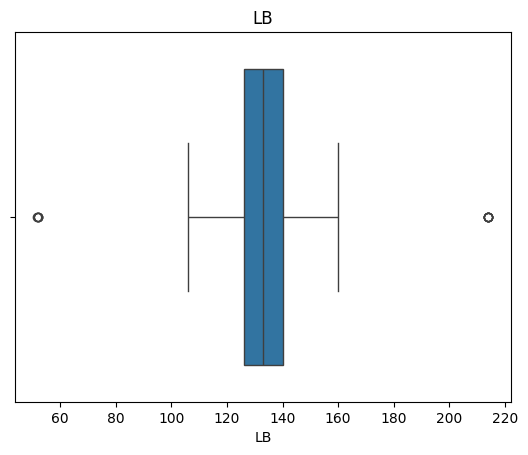

AC Outliers (Below -0.01 or Above 0.01): 43


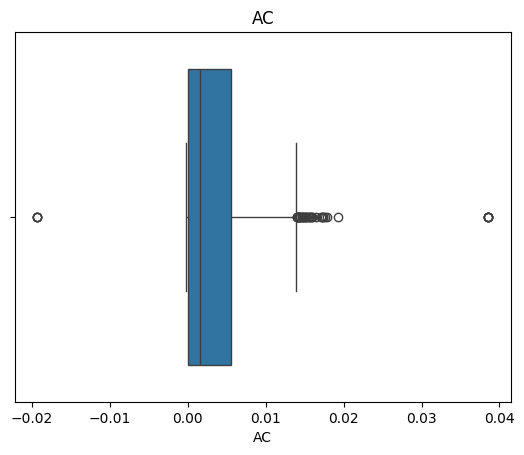

FM Outliers (Below -0.00 or Above 0.01): 347


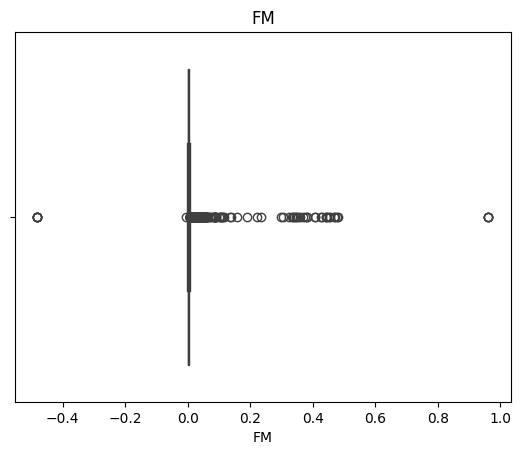

UC Outliers (Below -0.01 or Above 0.01): 13


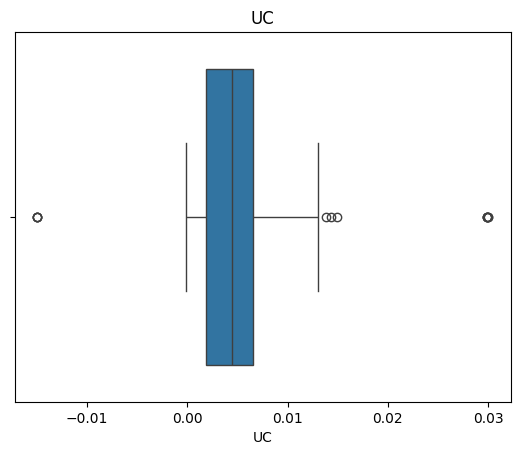

DL Outliers (Below -0.00 or Above 0.01): 125


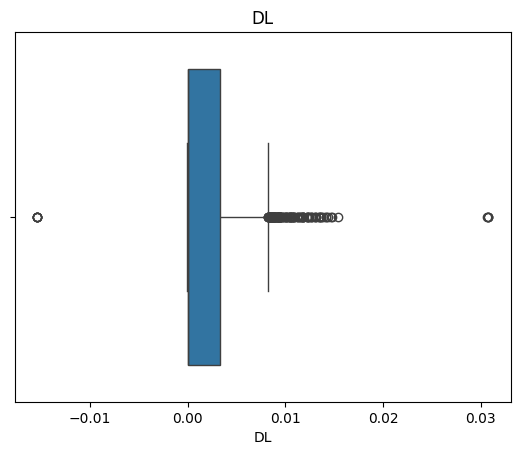

DS Outliers (Below 0.00 or Above 0.00): 120


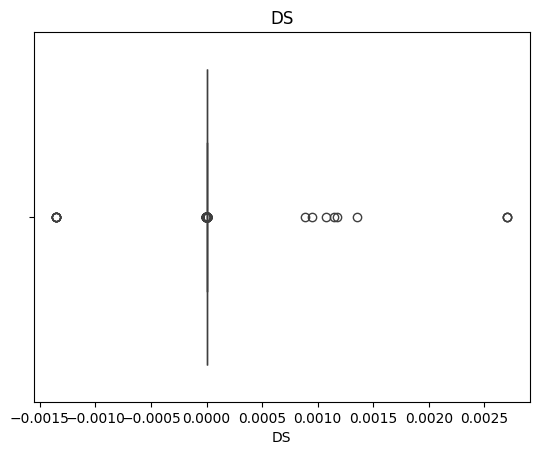

DP Outliers (Below 0.00 or Above 0.00): 284


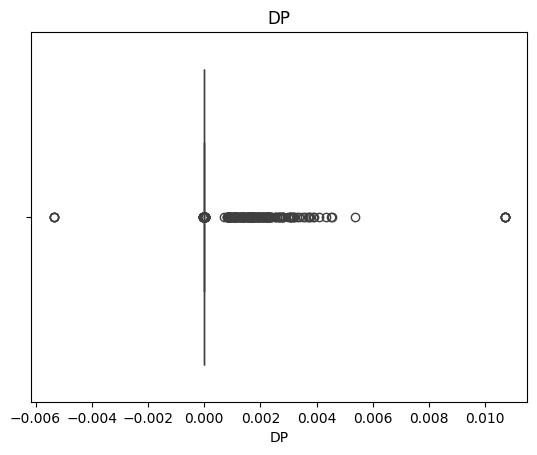

ASTV Outliers (Below -11.50 or Above 104.50): 10


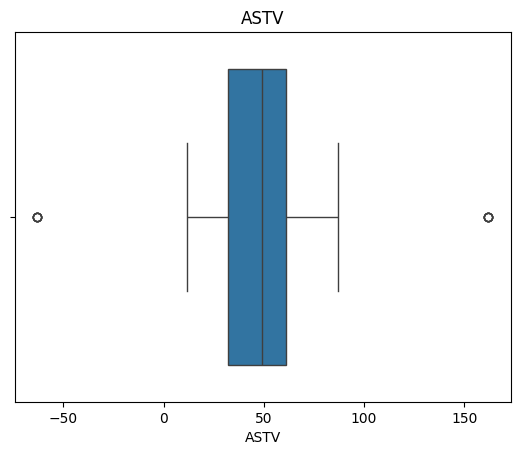

MSTV Outliers (Below -0.80 or Above 3.20): 80


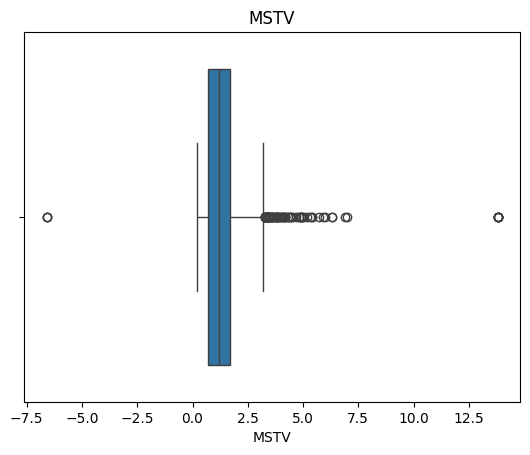

ALTV Outliers (Below -16.50 or Above 27.50): 318


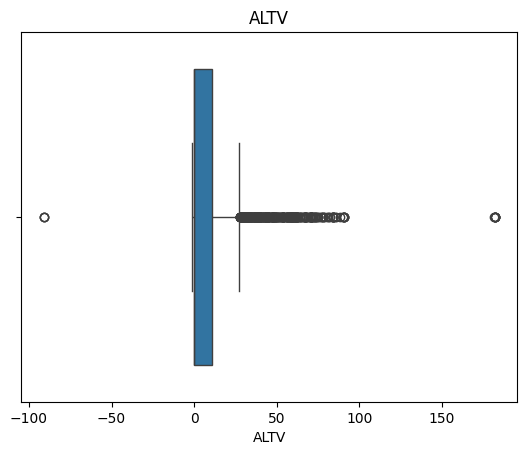

MLTV Outliers (Below -4.70 or Above 20.10): 81


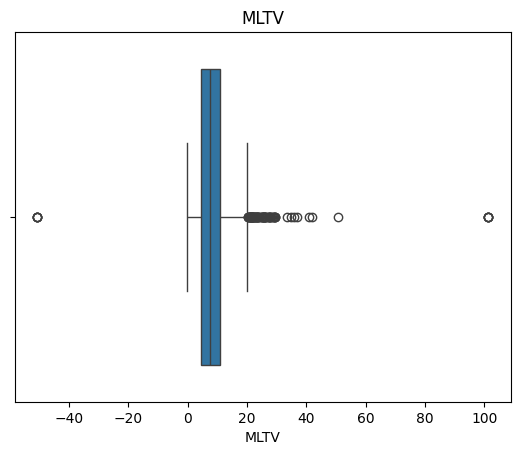

Width Outliers (Below -57.50 or Above 194.50): 10


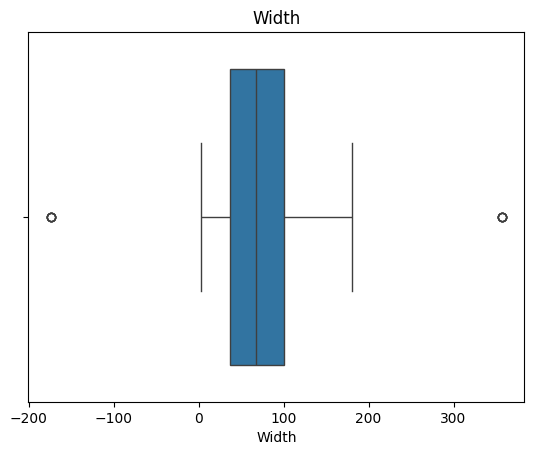

In [7]:
num_cols = ["LB", "AC", "FM", "UC", "DL", "DS", "DP", "ASTV", "MSTV", "ALTV", "MLTV", "Width"]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(f"{col} Outliers (Below {lower:.2f} or Above {upper:.2f}):", ((df[col] < lower) | (df[col] > upper)).sum())
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Outliers exist primarily in Fetal Movements (FM), decelerations (DL, DP), and variability measures (ALTV) indicating clinical anomalies. These outliers represent valid pathologic fetal states and are kept for downstream analysis.

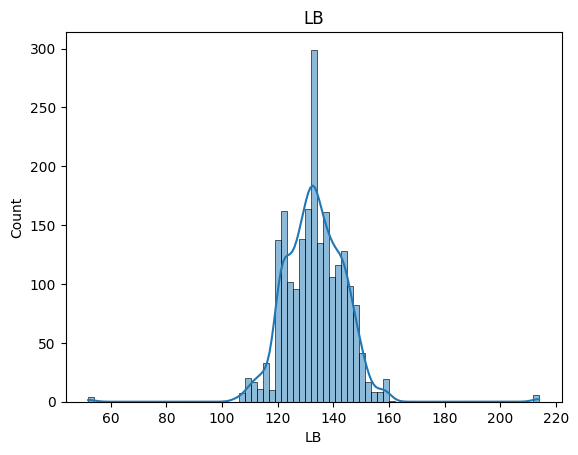

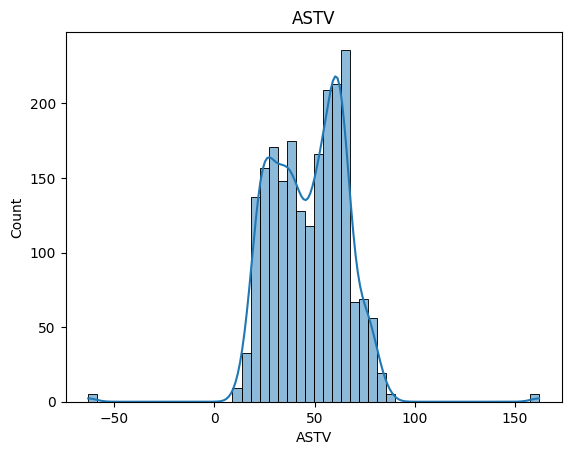

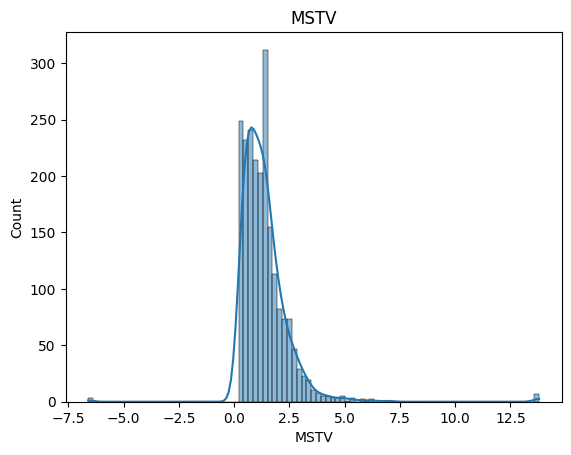

In [8]:
for col in ["LB", "ASTV", "MSTV"]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

LB shows a symmetric distribution centered around 133, while ASTV is bimodal, indicating split groups of low and high heart rate variability in fœtal readings.

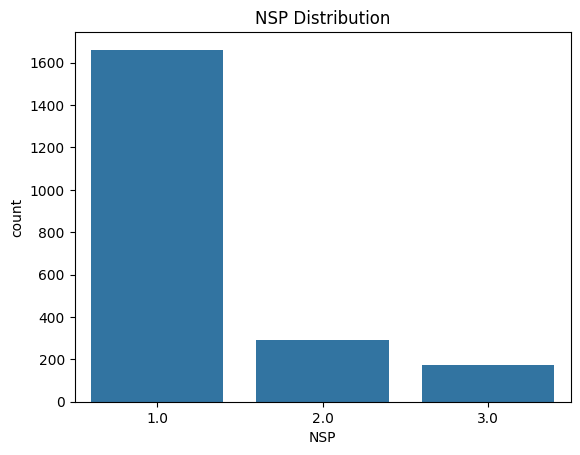

In [9]:
plt.figure()
sns.countplot(data=df, x="NSP")
plt.title("NSP Distribution")
plt.show()

NSP class distribution shows that the vast majority of cases are normal (class 1), with suspect (class 2) and pathologic (class 3) being minority classes.

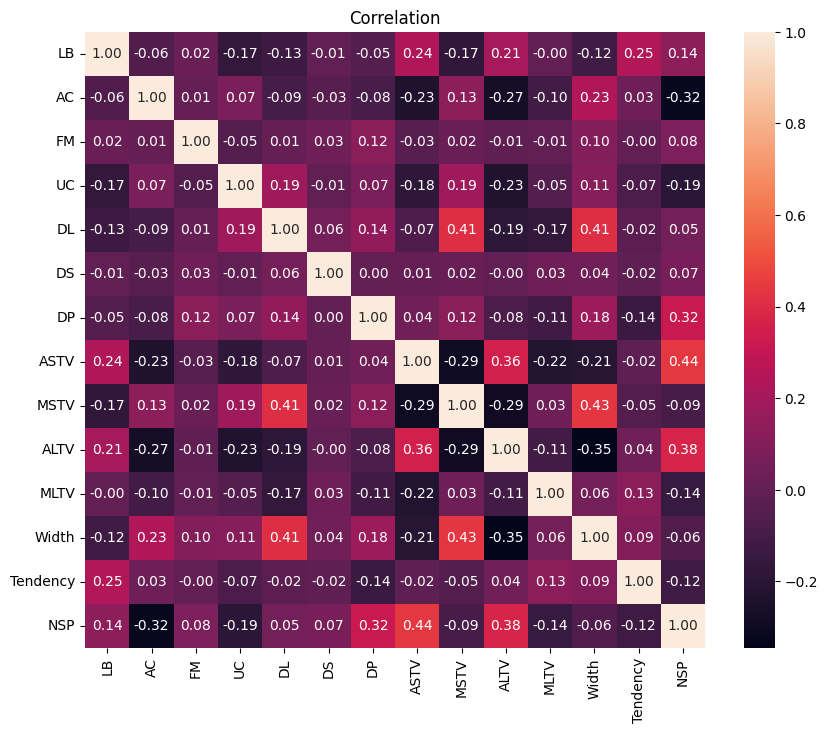

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation")
plt.show()

NSP classes show strong positive correlations with abnormal short-term variability (ASTV) and long-term variability (ALTV), suggesting these are key predictor features.

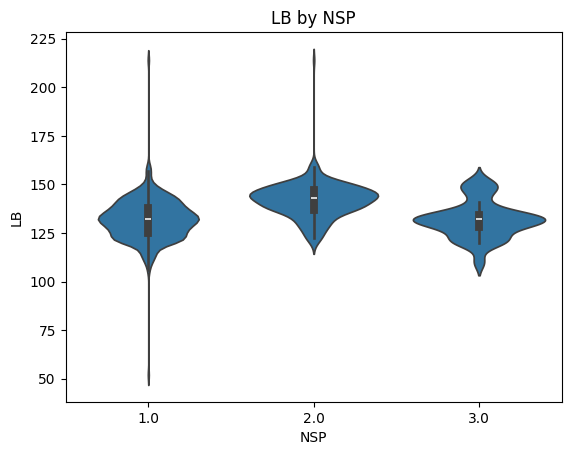

In [11]:
plt.figure()
sns.violinplot(data=df, x="NSP", y="LB")
plt.title("LB by NSP")
plt.show()

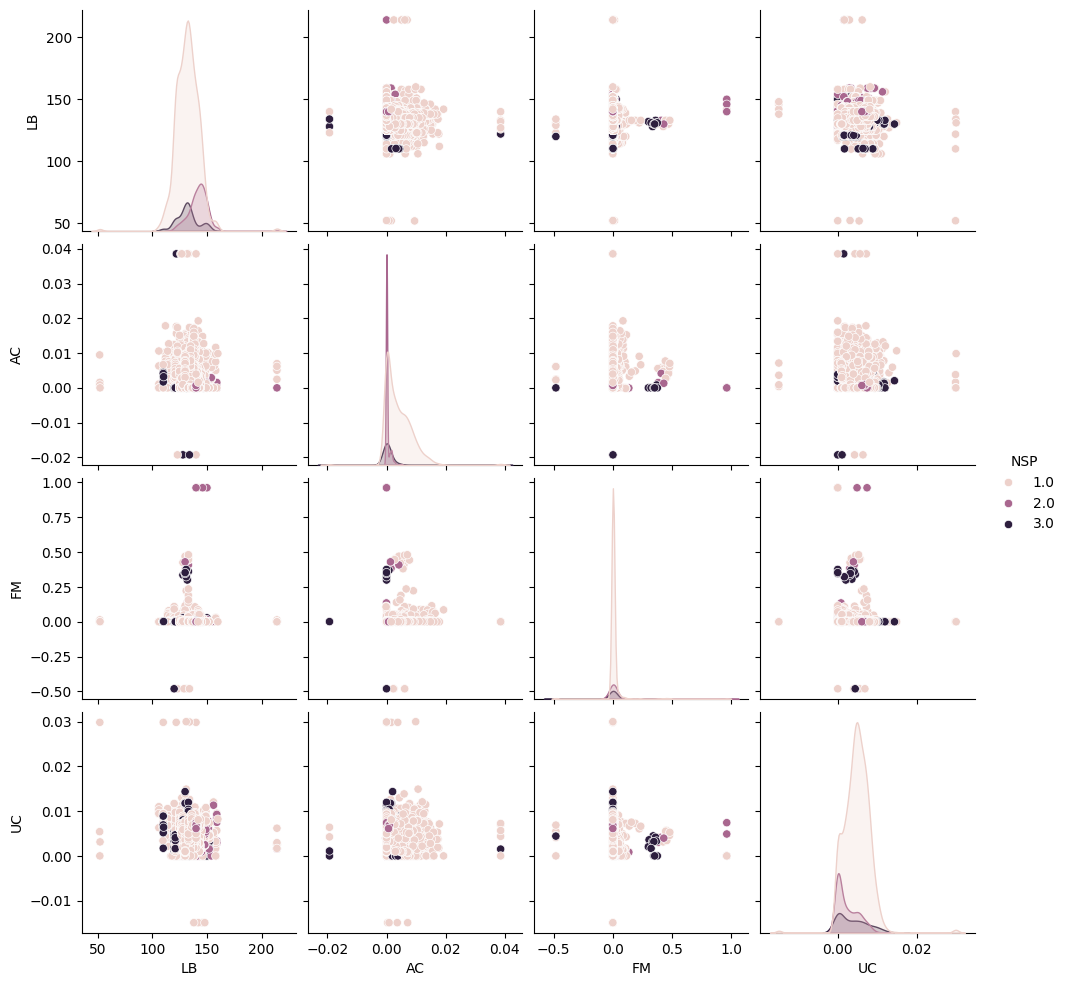

In [12]:
sns.pairplot(df[["LB", "AC", "FM", "UC", "NSP"]], hue="NSP")
plt.show()

The pairplot reveals that pathologic cases (NSP 3) are clustered in regions with very low acceleration rates (AC) and higher baseline heart rates (LB). Pattern analysis suggests that healthy fetuses have higher accelerations and standard baseline limits.